# Analysis

In [1]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from sklearn.metrics import jaccard_score

In [2]:
def res_load(csv_name: str):
    data = pd.read_csv(csv_name, sep=';').T
    data.columns = data.loc['metrics']
    data.drop(index='metrics', inplace=True)
    return data

def extract_mean(value):
    if isinstance(value, str):
        return float(value.split('$\\pm$')[0])
    else:
        return value

def jaccard_sim(data1, data2):
    data1 = np.array(data1)
    data2 = np.array(data2)
    # data1 = (data1 - data1.min()) / (data1.max() - data1.min())
    # data2 = (data2 - data2.min()) / (data2.max() - data2.min())
    return jaccard_score([x>0.5 for x in data1], [x>0.5 for x in data2])

def jaccard_heatmap(data):
    data = data[~data.index.str.contains('NCN')]
    res = np.zeros((len(data), len(data)))
    for idx in range(len(data)):
        for idx2 in range(len(data)):
            if idx < idx2:
                res[idx][idx2] = jaccard_sim(data.iloc[idx], data.iloc[idx2])
    res += np.transpose(res) + np.identity(len(data))
    heatmap(pd.DataFrame(res, index=data.index, columns=data.index), 'Corelation Overlap', False)

def heatmap(data: pd.DataFrame, Title: str, size: tuple[int, int]= (12, 12), normalized=True):
    data = data.copy()
    data = data.T
    if 'pretrain_time' in data.index:
        data = data.drop('pretrain_time')
    for column in data.columns:
        data[column] = data[column].apply(extract_mean).apply(np.mean)
    if normalized:
        normalized_data = (data - data.min(axis=1).values[:, np.newaxis]) / (data.max(axis=1).values[:, np.newaxis] - data.min(axis=1).values[:, np.newaxis])
    else:
        normalized_data = data
    fig, ax = plt.subplots(figsize=size)
    im = ax.imshow(normalized_data)

    plt.xticks(rotation=90)

    ax.set_yticks(range(len(data.index)), labels=data.index,
                  rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xticks(range(len(data.columns)), labels=data.columns)

    for i in range(len(data.index)):
        for j in range(len(data.columns)):
            text_color = 'white' if normalized_data.iloc[i, j] < np.mean(normalized_data) else 'black'
            text = ax.text(j, i, f"{data.iloc[i, j]:.2f}",
                           ha="center", va="center", color=text_color)

    ax.set_title(Title)
    fig.tight_layout()
    plt.show()

## Full Cora test

./full_output_cora_res.csv
\begin{tabular}{llllllll}
\toprule
metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & AP & pretrain_time \\
\midrule
baseline & 50.16$\pm$4.8 & 59.87$\pm$2.78 & 71.4$\pm$1.62 & 77.83$\pm$2.01 & 90.69$\pm$0.88 & 92.37$\pm$0.67 & nan$\pm$nan \\
grace_random & 48.9$\pm$4.88 & 60.19$\pm$2.76 & 73.33$\pm$1.73 & 80.69$\pm$1.6 & 91.45$\pm$0.81 & 92.96$\pm$0.6 & 19.04$\pm$0.13 \\
grace_deg & 29.73$\pm$6.42 & 46.25$\pm$6.56 & 67.6$\pm$2.94 & 80.91$\pm$1.33 & 91.95$\pm$0.58 & 92.17$\pm$0.69 & 19.19$\pm$0.08 \\
grace_pr & 31.23$\pm$7.11 & 45.55$\pm$7.04 & 67.26$\pm$5.77 & 80.98$\pm$3.51 & 92.13$\pm$1.14 & 92.33$\pm$1.19 & 19.15$\pm$0.02 \\
grace_evc & 33.4$\pm$5.46 & 47.57$\pm$6.06 & 68.09$\pm$3.75 & 79.82$\pm$3.37 & 91.92$\pm$0.68 & 92.32$\pm$0.81 & 19.15$\pm$0.04 \\
grace_scom & 48.88$\pm$6.25 & 61.23$\pm$4.28 & 74.83$\pm$1.53 & 81.59$\pm$1.4 & 91.79$\pm$0.71 & 93.3$\pm$0.44 & 20.27$\pm$0.09 \\
grace_sbm & 34.93$\pm$4.84 & 43.95$\pm$3.63 & 56.82$\pm$2.11 & 66

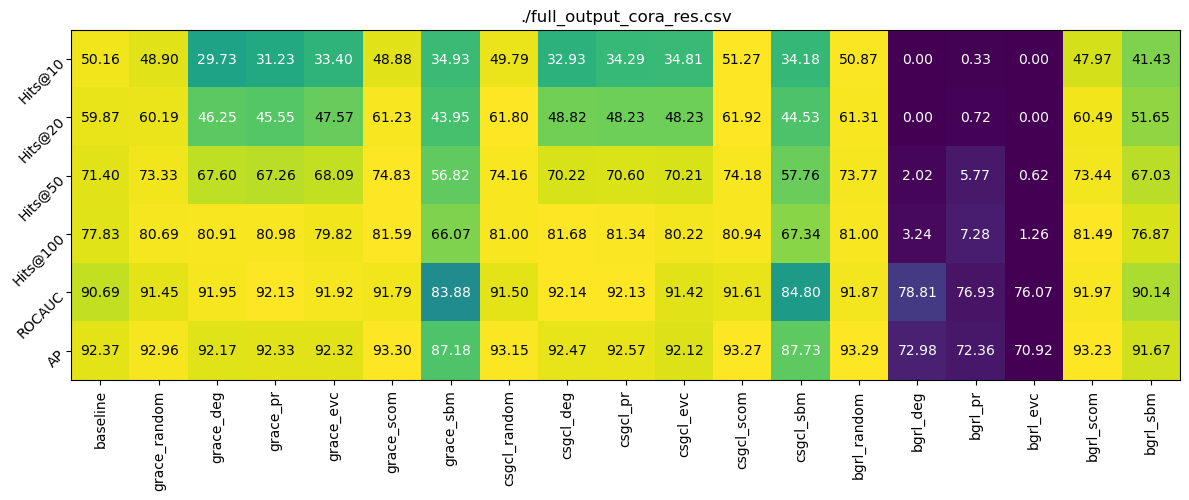

,baseline,grace_random,grace_deg,grace_pr,grace_evc,grace_scom,grace_sbm,csgcl_random,csgcl_deg,csgcl_pr,csgcl_evc,csgcl_scom,csgcl_sbm,bgrl_random,bgrl_deg,bgrl_pr,bgrl_evc,bgrl_scom,bgrl_sbm
metrics,,,,,,,,,,,,,,,,,,,
Hits@10,50.16$\pm$4.8,48.9$\pm$4.88,29.73$\pm$6.42,31.23$\pm$7.11,33.4$\pm$5.46,48.88$\pm$6.25,34.93$\pm$4.84,49.79$\pm$5.65,32.93$\pm$5.69,34.29$\pm$7.8,34.81$\pm$5.86,51.27$\pm$4.74,34.18$\pm$4.06,50.87$\pm$8.4,0.0$\pm$0.0,0.33$\pm$1.0,0.0$\pm$0.0,47.97$\pm$9.93,41.43$\pm$9.67
Hits@20,59.87$\pm$2.78,60.19$\pm$2.76,46.25$\pm$6.56,45.55$\pm$7.04,47.57$\pm$6.06,61.23$\pm$4.28,43.95$\pm$3.63,61.8$\pm$3.21,48.82$\pm$5.59,48.23$\pm$6.12,48.23$\pm$6.6,61.92$\pm$2.28,44.53$\pm$4.94,61.31$\pm$7.1,0.0$\pm$0.0,0.72$\pm$2.16,0.0$\pm$0.0,60.49$\pm$8.72,51.65$\pm$8.21
Hits@50,71.4$\pm$1.62,73.33$\pm$1.73,67.6$\pm$2.94,67.26$\pm$5.77,68.09$\pm$3.75,74.83$\pm$1.53,56.82$\pm$2.11,74.16$\pm$1.37,70.22$\pm$3.9,70.6$\pm$3.75,70.21$\pm$3.58,74.18$\pm$1.78,57.76$\pm$2.0,73.77$\pm$3.23,2.02$\pm$6.06,5.77$\pm$13.32,0.62$\pm$1.85,73.44$\pm$2.55,67.03$\pm$7.43
Hits@100,77.83$\pm$2.01,80.69$\pm$1.6,80.91$\pm$1.33,80.98$\pm$3.51,79.82$\pm$3.37,81.59$\pm$1.4,66.07$\pm$2.04,81.0$\pm$1.57,81.68$\pm$2.01,81.34$\pm$1.0,80.22$\pm$2.28,80.94$\pm$0.86,67.34$\pm$1.44,81.0$\pm$1.32,3.24$\pm$9.73,7.28$\pm$16.34,1.26$\pm$3.78,81.49$\pm$1.35,76.87$\pm$4.31
ROCAUC,90.69$\pm$0.88,91.45$\pm$0.81,91.95$\pm$0.58,92.13$\pm$1.14,91.92$\pm$0.68,91.79$\pm$0.71,83.88$\pm$1.02,91.5$\pm$1.04,92.14$\pm$0.79,92.13$\pm$0.55,91.42$\pm$0.97,91.61$\pm$0.55,84.8$\pm$1.02,91.87$\pm$0.71,78.81$\pm$4.54,76.93$\pm$7.69,76.07$\pm$8.37,91.97$\pm$1.01,90.14$\pm$1.26
AP,92.37$\pm$0.67,92.96$\pm$0.6,92.17$\pm$0.69,92.33$\pm$1.19,92.32$\pm$0.81,93.3$\pm$0.44,87.18$\pm$0.72,93.15$\pm$0.63,92.47$\pm$0.65,92.57$\pm$0.49,92.12$\pm$0.88,93.27$\pm$0.38,87.73$\pm$0.78,93.29$\pm$0.71,72.98$\pm$4.74,72.36$\pm$6.79,70.92$\pm$7.4,93.23$\pm$0.53,91.67$\pm$1.51
pretrain_time,nan$\pm$nan,19.04$\pm$0.13,19.19$\pm$0.08,19.15$\pm$0.02,19.15$\pm$0.04,20.27$\pm$0.09,866.8$\pm$23.27,20.67$\pm$0.09,20.74$\pm$0.13,20.7$\pm$0.09,20.67$\pm$0.04,22.3$\pm$0.17,895.48$\pm$32.54,19.01$\pm$0.1,19.45$\pm$0.09,18.95$\pm$0.52,18.1$\pm$0.11,19.36$\pm$0.06,846.79$\pm$30.39


In [8]:
name = './full_output_cora_res.csv'
data = res_load(name)

print(name)
print(data.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data, name)
display(data.T)

## SBM sur synthetic et cora

./sbm_full_synthetic_1_res.csv


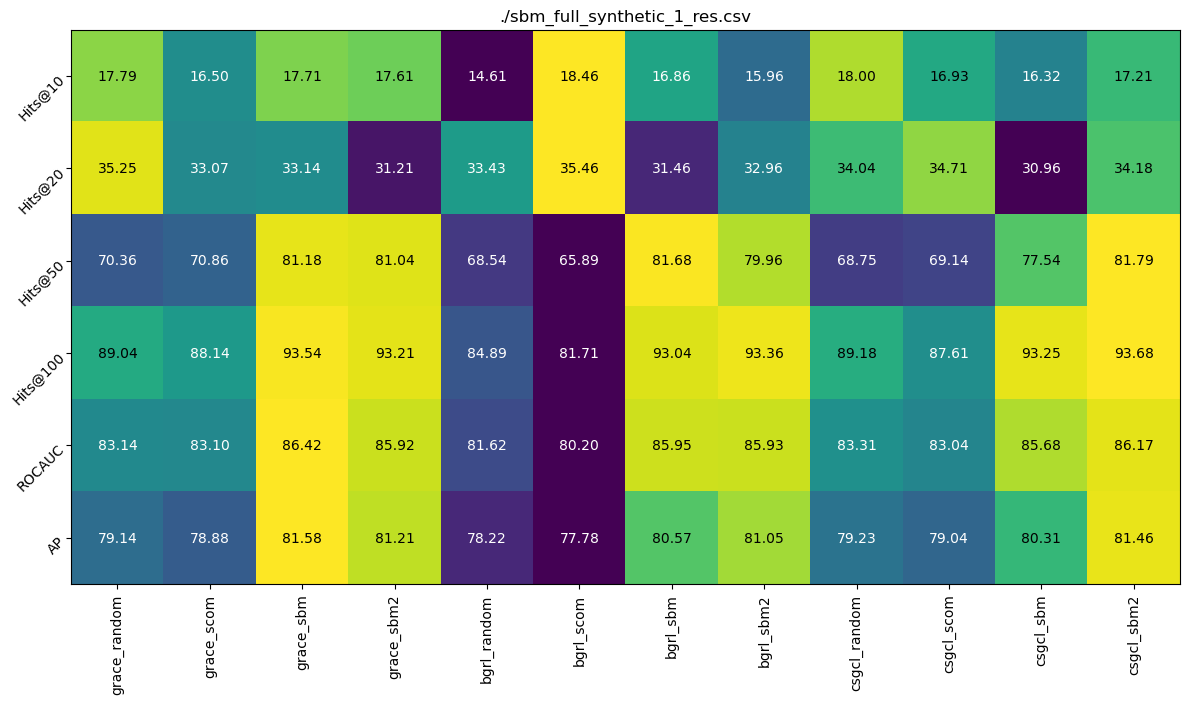

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,17.79$\pm$7.26,16.5$\pm$6.84,17.71$\pm$5.37,17.61$\pm$5.64,14.61$\pm$5.13,18.46$\pm$5.39,16.86$\pm$6.29,15.96$\pm$6.4,18.0$\pm$7.55,16.93$\pm$5.01,16.32$\pm$3.46,17.21$\pm$4.68
Hits@20,35.25$\pm$9.67,33.07$\pm$7.54,33.14$\pm$8.16,31.21$\pm$5.66,33.43$\pm$4.9,35.46$\pm$7.6,31.46$\pm$7.55,32.96$\pm$7.97,34.04$\pm$7.78,34.71$\pm$10.31,30.96$\pm$8.71,34.18$\pm$6.47
Hits@50,70.36$\pm$4.24,70.86$\pm$5.75,81.18$\pm$10.02,81.04$\pm$11.84,68.54$\pm$4.18,65.89$\pm$5.62,81.68$\pm$8.13,79.96$\pm$10.64,68.75$\pm$4.41,69.14$\pm$4.3,77.54$\pm$9.67,81.79$\pm$9.16
Hits@100,89.04$\pm$0.6,88.14$\pm$2.23,93.54$\pm$1.12,93.21$\pm$1.01,84.89$\pm$2.36,81.71$\pm$3.6,93.04$\pm$0.7,93.36$\pm$0.89,89.18$\pm$1.86,87.61$\pm$1.81,93.25$\pm$1.4,93.68$\pm$0.78
ROCAUC,83.14$\pm$1.49,83.1$\pm$1.4,86.42$\pm$1.6,85.92$\pm$1.75,81.62$\pm$1.29,80.2$\pm$2.44,85.95$\pm$1.6,85.93$\pm$1.9,83.31$\pm$1.48,83.04$\pm$1.59,85.68$\pm$1.71,86.17$\pm$1.64
AP,79.14$\pm$2.4,78.88$\pm$2.35,81.58$\pm$2.58,81.21$\pm$2.81,78.22$\pm$2.21,77.78$\pm$2.43,80.57$\pm$2.55,81.05$\pm$2.6,79.23$\pm$2.53,79.04$\pm$2.52,80.31$\pm$2.55,81.46$\pm$2.34
pretrain_time,4.08$\pm$0.1,4.68$\pm$0.01,33.48$\pm$0.23,62.35$\pm$0.15,5.24$\pm$0.03,5.73$\pm$0.03,31.53$\pm$0.18,59.21$\pm$0.19,4.23$\pm$0.04,4.78$\pm$0.05,31.36$\pm$0.43,59.37$\pm$0.29


In [5]:
name = './sbm_full_synthetic_1_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name)
display(data.T)

./sbm_full_synthetic_2_res.csv


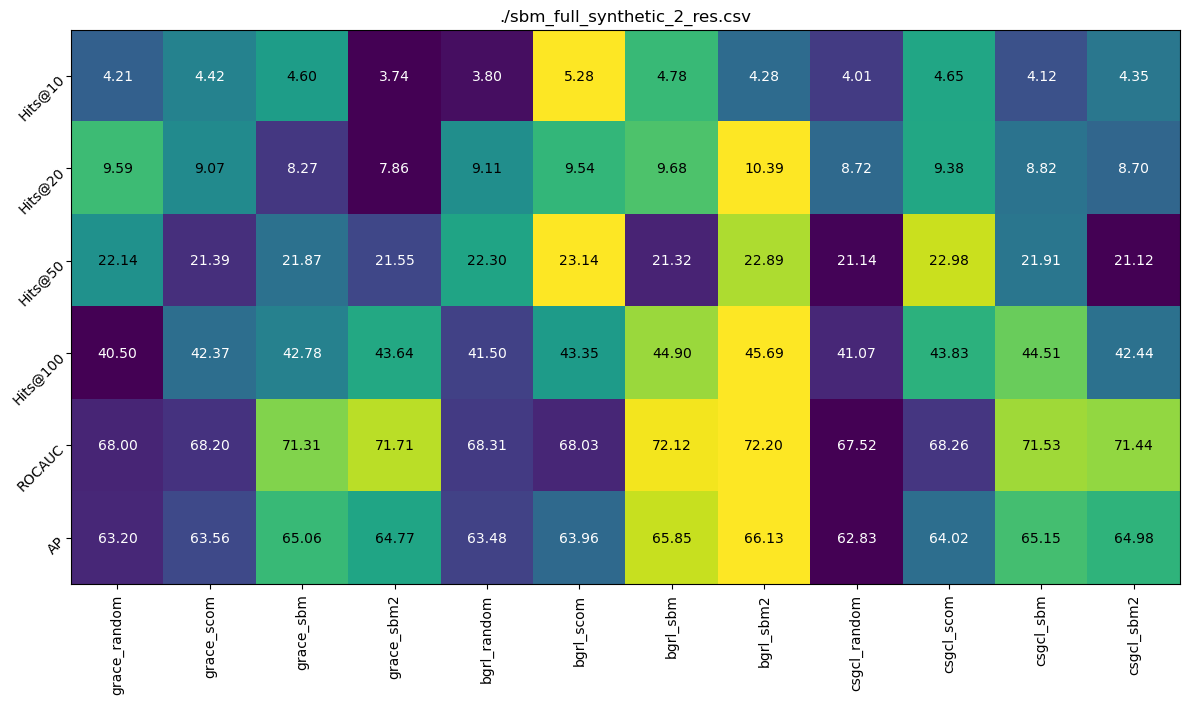

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,4.21$\pm$1.93,4.42$\pm$0.92,4.6$\pm$1.26,3.74$\pm$1.5,3.8$\pm$1.7,5.28$\pm$1.57,4.78$\pm$1.69,4.28$\pm$1.75,4.01$\pm$1.44,4.65$\pm$1.22,4.12$\pm$1.62,4.35$\pm$2.53
Hits@20,9.59$\pm$2.41,9.07$\pm$2.06,8.27$\pm$1.92,7.86$\pm$2.03,9.11$\pm$2.59,9.54$\pm$1.77,9.68$\pm$2.45,10.39$\pm$2.07,8.72$\pm$2.03,9.38$\pm$2.08,8.82$\pm$2.3,8.7$\pm$3.22
Hits@50,22.14$\pm$4.09,21.39$\pm$4.06,21.87$\pm$2.69,21.55$\pm$2.52,22.3$\pm$2.7,23.14$\pm$5.6,21.32$\pm$3.88,22.89$\pm$2.82,21.14$\pm$2.58,22.98$\pm$4.05,21.91$\pm$2.88,21.12$\pm$3.54
Hits@100,40.5$\pm$5.55,42.37$\pm$4.4,42.78$\pm$3.2,43.64$\pm$3.57,41.5$\pm$2.49,43.35$\pm$5.29,44.9$\pm$5.4,45.69$\pm$5.24,41.07$\pm$3.66,43.83$\pm$4.44,44.51$\pm$3.94,42.44$\pm$3.27
ROCAUC,68.0$\pm$2.32,68.2$\pm$2.15,71.31$\pm$1.51,71.71$\pm$1.48,68.31$\pm$2.92,68.03$\pm$3.26,72.12$\pm$1.57,72.2$\pm$1.94,67.52$\pm$2.26,68.26$\pm$2.71,71.53$\pm$1.44,71.44$\pm$1.57
AP,63.2$\pm$2.67,63.56$\pm$2.21,65.06$\pm$1.51,64.77$\pm$1.77,63.48$\pm$2.62,63.96$\pm$3.21,65.85$\pm$2.32,66.13$\pm$2.27,62.83$\pm$2.43,64.02$\pm$2.56,65.15$\pm$1.91,64.98$\pm$1.81
pretrain_time,3.96$\pm$0.05,4.55$\pm$0.05,47.69$\pm$0.26,91.37$\pm$0.69,4.89$\pm$0.04,5.47$\pm$0.04,47.25$\pm$0.33,90.88$\pm$0.53,4.17$\pm$0.07,4.76$\pm$0.04,48.1$\pm$0.41,91.92$\pm$1.04


In [6]:
name = './sbm_full_synthetic_2_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name)
display(data.T)

./sbm_full_synthetic_3_res.csv


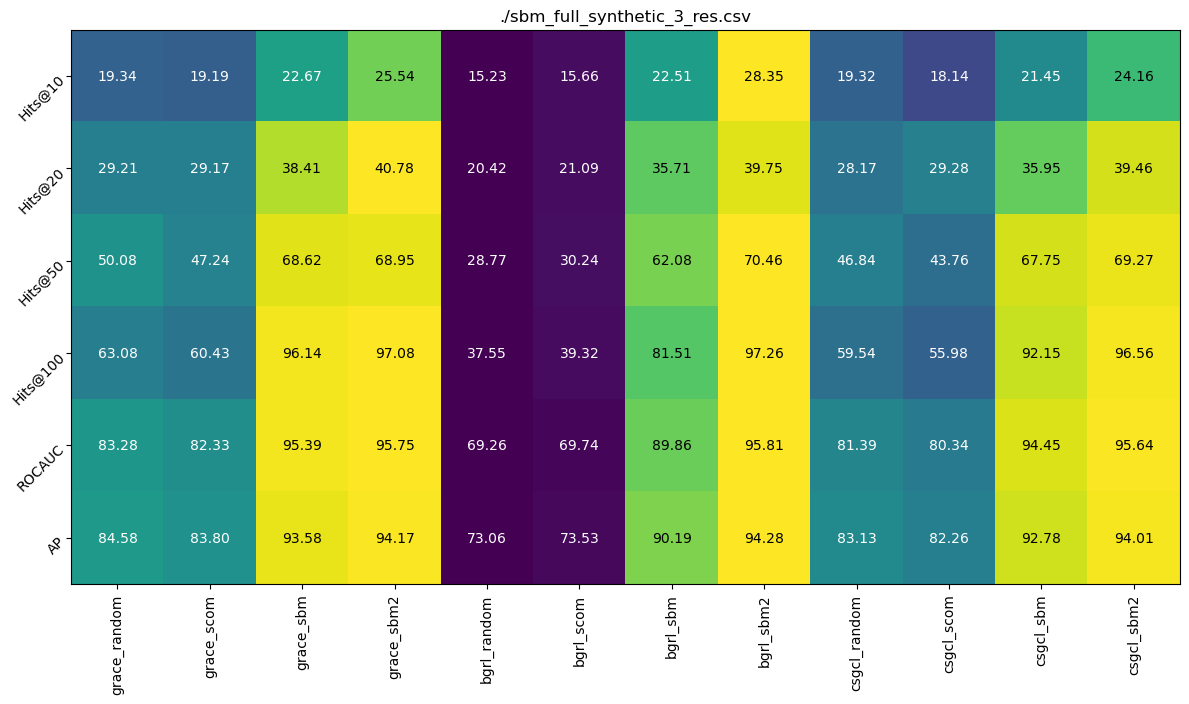

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,19.34$\pm$4.15,19.19$\pm$2.74,22.67$\pm$6.13,25.54$\pm$5.67,15.23$\pm$2.37,15.66$\pm$3.57,22.51$\pm$5.06,28.35$\pm$6.23,19.32$\pm$4.25,18.14$\pm$2.39,21.45$\pm$5.94,24.16$\pm$6.63
Hits@20,29.21$\pm$4.44,29.17$\pm$4.24,38.41$\pm$9.15,40.78$\pm$7.11,20.42$\pm$2.42,21.09$\pm$2.47,35.71$\pm$6.88,39.75$\pm$6.29,28.17$\pm$3.91,29.28$\pm$3.54,35.95$\pm$8.11,39.46$\pm$6.89
Hits@50,50.08$\pm$3.33,47.24$\pm$3.29,68.62$\pm$6.61,68.95$\pm$8.8,28.77$\pm$1.88,30.24$\pm$1.61,62.08$\pm$5.08,70.46$\pm$8.64,46.84$\pm$3.1,43.76$\pm$2.63,67.75$\pm$7.61,69.27$\pm$8.01
Hits@100,63.08$\pm$1.66,60.43$\pm$2.02,96.14$\pm$1.98,97.08$\pm$2.71,37.55$\pm$2.57,39.32$\pm$1.69,81.51$\pm$7.9,97.26$\pm$2.35,59.54$\pm$2.13,55.98$\pm$2.03,92.15$\pm$2.47,96.56$\pm$2.03
ROCAUC,83.28$\pm$0.68,82.33$\pm$0.91,95.39$\pm$0.71,95.75$\pm$0.6,69.26$\pm$1.66,69.74$\pm$0.94,89.86$\pm$3.55,95.81$\pm$0.59,81.39$\pm$1.22,80.34$\pm$0.98,94.45$\pm$0.68,95.64$\pm$0.62
AP,84.58$\pm$0.6,83.8$\pm$0.97,93.58$\pm$1.19,94.17$\pm$0.94,73.06$\pm$1.57,73.53$\pm$0.81,90.19$\pm$2.24,94.28$\pm$0.84,83.13$\pm$1.14,82.26$\pm$0.9,92.78$\pm$1.1,94.01$\pm$0.92
pretrain_time,6.92$\pm$0.01,7.56$\pm$0.01,177.71$\pm$0.41,350.9$\pm$1.0,6.46$\pm$0.03,7.03$\pm$0.02,178.35$\pm$0.39,351.51$\pm$1.06,7.42$\pm$0.04,7.9$\pm$0.05,177.93$\pm$0.22,350.53$\pm$0.97


In [7]:
name = './sbm_full_synthetic_3_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name)
display(data.T)

./sbm_full_cora_res.csv


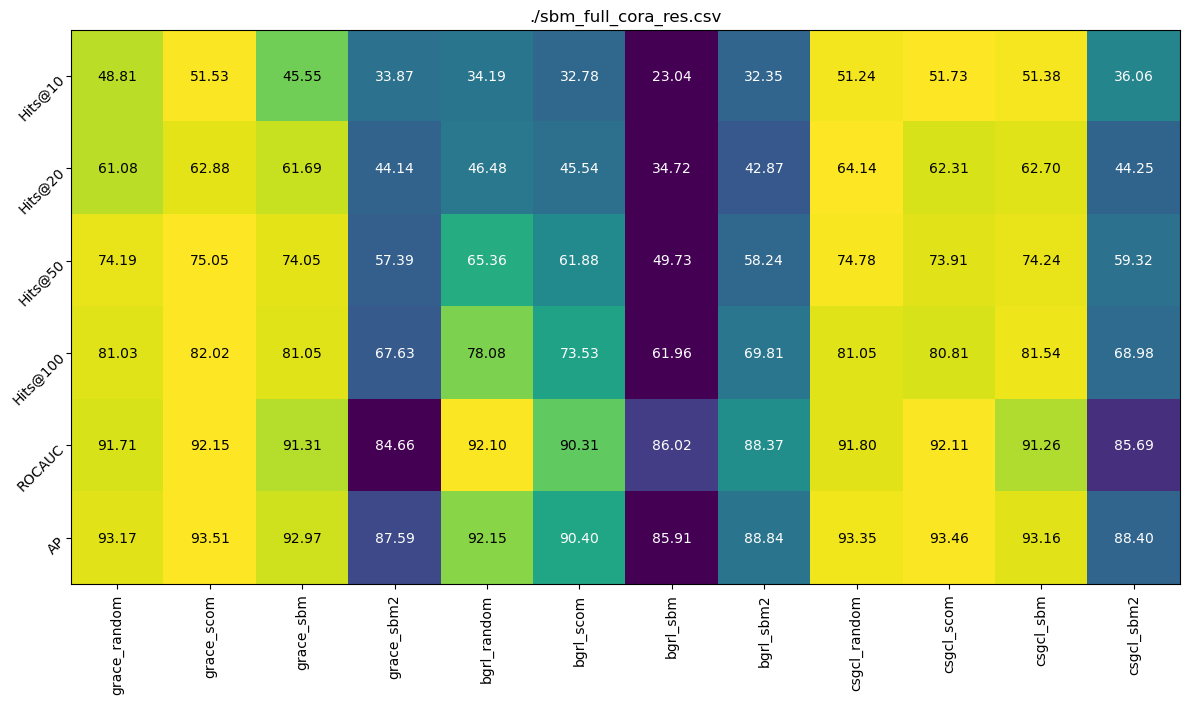

,grace_random,grace_scom,grace_sbm,grace_sbm2,bgrl_random,bgrl_scom,bgrl_sbm,bgrl_sbm2,csgcl_random,csgcl_scom,csgcl_sbm,csgcl_sbm2
metrics,,,,,,,,,,,,
Hits@10,48.81$\pm$4.21,51.53$\pm$4.99,45.55$\pm$6.71,33.87$\pm$3.08,34.19$\pm$6.69,32.78$\pm$13.51,23.04$\pm$11.89,32.35$\pm$13.55,51.24$\pm$4.54,51.73$\pm$3.4,51.38$\pm$4.99,36.06$\pm$3.66
Hits@20,61.08$\pm$3.09,62.88$\pm$2.16,61.69$\pm$4.64,44.14$\pm$2.48,46.48$\pm$6.42,45.54$\pm$14.39,34.72$\pm$15.35,42.87$\pm$15.22,64.14$\pm$2.19,62.31$\pm$3.06,62.7$\pm$4.11,44.25$\pm$2.66
Hits@50,74.19$\pm$1.7,75.05$\pm$0.82,74.05$\pm$1.86,57.39$\pm$2.7,65.36$\pm$5.51,61.88$\pm$16.1,49.73$\pm$17.42,58.24$\pm$16.63,74.78$\pm$1.8,73.91$\pm$1.35,74.24$\pm$1.91,59.32$\pm$1.9
Hits@100,81.03$\pm$1.68,82.02$\pm$0.83,81.05$\pm$1.57,67.63$\pm$2.3,78.08$\pm$4.21,73.53$\pm$15.19,61.96$\pm$17.22,69.81$\pm$16.48,81.05$\pm$0.97,80.81$\pm$1.46,81.54$\pm$1.58,68.98$\pm$1.74
ROCAUC,91.71$\pm$1.01,92.15$\pm$0.44,91.31$\pm$0.8,84.66$\pm$1.36,92.1$\pm$1.03,90.31$\pm$5.91,86.02$\pm$8.6,88.37$\pm$6.56,91.8$\pm$0.73,92.11$\pm$0.64,91.26$\pm$0.78,85.69$\pm$1.17
AP,93.17$\pm$0.7,93.51$\pm$0.2,92.97$\pm$0.58,87.59$\pm$0.97,92.15$\pm$1.19,90.4$\pm$6.21,85.91$\pm$8.51,88.84$\pm$6.64,93.35$\pm$0.4,93.46$\pm$0.38,93.16$\pm$0.5,88.4$\pm$0.82
pretrain_time,6.24$\pm$0.01,6.72$\pm$0.02,148.78$\pm$5.04,293.63$\pm$10.0,5.74$\pm$0.01,6.27$\pm$0.02,149.48$\pm$5.05,293.61$\pm$9.91,6.71$\pm$0.05,7.19$\pm$0.06,148.82$\pm$4.99,293.08$\pm$9.61


In [8]:
name = './sbm_full_cora_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name)
display(data.T)

## SBM: Cora full vs CORA - test

SBM full vs -test cora
\begin{tabular}{lllllllll}
\toprule
 & metrics & Hits@10 & Hits@20 & Hits@50 & Hits@100 & ROCAUC & AP & pretrain_time \\
\midrule
\multirow[t]{4}{*}{full} & baseline & 46.82$\pm$0.0 & 55.26$\pm$0.0 & 68.25$\pm$0.0 & 77.16$\pm$0.0 & 90.45$\pm$0.0 & 91.84$\pm$0.0 & nan$\pm$nan \\
 & grace_sbm & 27.68$\pm$0.0 & 42.18$\pm$0.0 & 58.2$\pm$0.0 & 65.88$\pm$0.0 & 83.88$\pm$0.0 & 86.77$\pm$0.0 & 135.02$\pm$0.0 \\
 & csgcl_sbm & 36.02$\pm$0.0 & 48.82$\pm$0.0 & 58.86$\pm$0.0 & 68.44$\pm$0.0 & 85.37$\pm$0.0 & 88.41$\pm$0.0 & 135.5$\pm$0.0 \\
 & bgrl_sbm & 29.29$\pm$0.0 & 39.05$\pm$0.0 & 51.56$\pm$0.0 & 65.97$\pm$0.0 & 89.29$\pm$0.0 & 89.24$\pm$0.0 & 135.32$\pm$0.0 \\
\cline{1-9}
\multirow[t]{4}{*}{-test} & baseline & 46.82$\pm$0.0 & 55.26$\pm$0.0 & 68.25$\pm$0.0 & 77.16$\pm$0.0 & 90.45$\pm$0.0 & 91.84$\pm$0.0 & nan$\pm$nan \\
 & grace_sbm & 38.1$\pm$0.0 & 45.31$\pm$0.0 & 57.54$\pm$0.0 & 68.72$\pm$0.0 & 85.93$\pm$0.0 & 88.55$\pm$0.0 & 144.55$\pm$0.0 \\
 & csgcl_sbm & 33.18$\pm

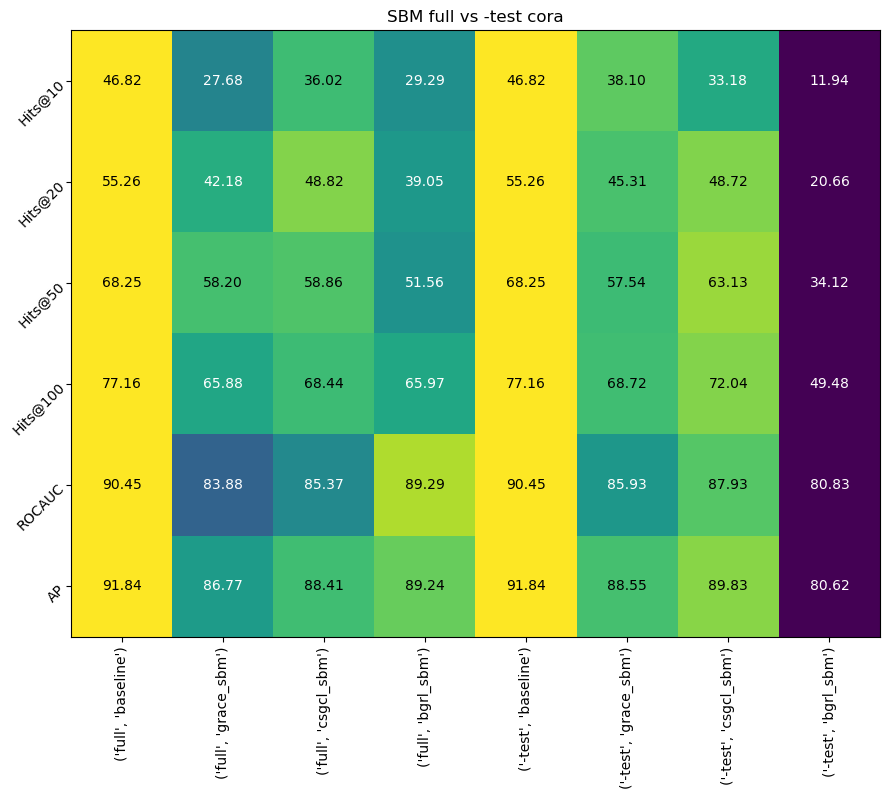

full                                                 \
                    baseline       grace_sbm      csgcl_sbm        bgrl_sbm   
metrics                                                                       
Hits@10        46.82$\pm$0.0   27.68$\pm$0.0  36.02$\pm$0.0   29.29$\pm$0.0   
Hits@20        55.26$\pm$0.0   42.18$\pm$0.0  48.82$\pm$0.0   39.05$\pm$0.0   
Hits@50        68.25$\pm$0.0    58.2$\pm$0.0  58.86$\pm$0.0   51.56$\pm$0.0   
Hits@100       77.16$\pm$0.0   65.88$\pm$0.0  68.44$\pm$0.0   65.97$\pm$0.0   
ROCAUC         90.45$\pm$0.0   83.88$\pm$0.0  85.37$\pm$0.0   89.29$\pm$0.0   
AP             91.84$\pm$0.0   86.77$\pm$0.0  88.41$\pm$0.0   89.24$\pm$0.0   
pretrain_time    nan$\pm$nan  135.02$\pm$0.0  135.5$\pm$0.0  135.32$\pm$0.0   

                       -test                                                  
                    baseline       grace_sbm       csgcl_sbm        bgrl_sbm  
metrics                                                                       
Hits@10        46.82$\pm$0.0    38.1$\pm$0.0   33.18$\pm$0.0   11.94$\pm$0.0  
Hits@20        55.26$\pm$0.0   45.31$\pm$0.0   48.72$\pm$0.0   20.66$\pm$0.0  
Hits@50        68.25$\pm$0.0   57.54$\pm$0.0   63.13$\pm$0.0   34.12$\pm$0.0  
Hits@100       77.16$\pm$0.0   68.72$\pm$0.0   72.04$\pm$0.0   49.48$\pm$0.0  
ROCAUC         90.45$\pm$0.0   85.93$\pm$0.0   87.93$\pm$0.0   80.83$\pm$0.0  
AP             91.84$\pm$0.0   88.55$\pm$0.0   89.83$\pm$0.0   80.62$\pm$0.0  
pretrain_time    nan$\pm$nan  144.55$\pm$0.0  144.32$\pm$0.0  144.34$\pm$0.0

In [11]:
name_1 = './cora_sbm_full_res.csv'
data_1 = res_load(name_1)

name_2 = './cora-test_sbm_res.csv'
data_2 = res_load(name_2)

data_sbm = pd.concat([data_1, data_2], keys=['full', '-test'])

print('SBM full vs -test cora')
print(data_sbm.to_latex(
        index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
    ))
heatmap(data_sbm, 'SBM full vs -test cora', (9,9))
display(data_sbm.T)

## loss tuning

./scgc_bgrl_cora_res.csv


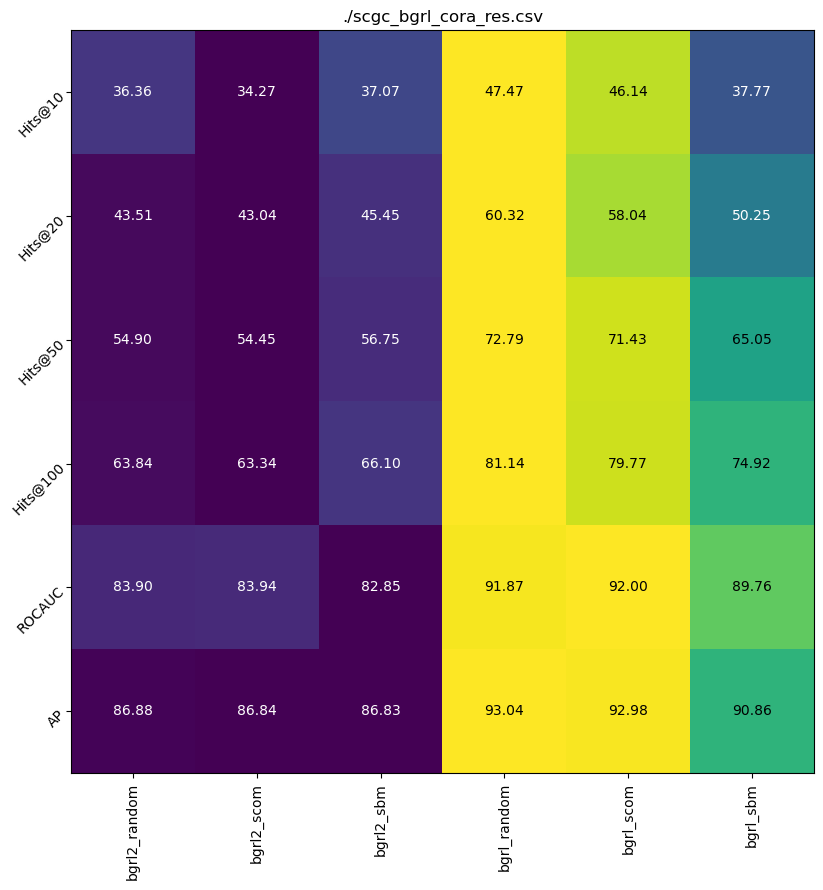

,bgrl2_random,bgrl2_scom,bgrl2_sbm,bgrl_random,bgrl_scom,bgrl_sbm
metrics,,,,,,
Hits@10,36.36$\pm$4.68,34.27$\pm$4.08,37.07$\pm$4.87,47.47$\pm$9.35,46.14$\pm$11.04,37.77$\pm$10.71
Hits@20,43.51$\pm$4.09,43.04$\pm$4.29,45.45$\pm$2.84,60.32$\pm$6.76,58.04$\pm$11.15,50.25$\pm$12.5
Hits@50,54.9$\pm$3.33,54.45$\pm$2.25,56.75$\pm$3.17,72.79$\pm$3.74,71.43$\pm$7.98,65.05$\pm$11.68
Hits@100,63.84$\pm$3.16,63.34$\pm$2.62,66.1$\pm$2.62,81.14$\pm$2.1,79.77$\pm$4.62,74.92$\pm$9.24
ROCAUC,83.9$\pm$1.52,83.94$\pm$1.59,82.85$\pm$1.43,91.87$\pm$1.08,92.0$\pm$0.91,89.76$\pm$2.91
AP,86.88$\pm$1.26,86.84$\pm$1.31,86.83$\pm$1.16,93.04$\pm$0.74,92.98$\pm$1.36,90.86$\pm$3.3
pretrain_time,17.21$\pm$5.5,25.22$\pm$7.97,1117.55$\pm$39.84,20.9$\pm$0.25,23.37$\pm$0.68,981.47$\pm$39.56


In [3]:
name = './scgc_bgrl_cora_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name, (9,9))
display(data.T)

./cgrace_cora_res.csv


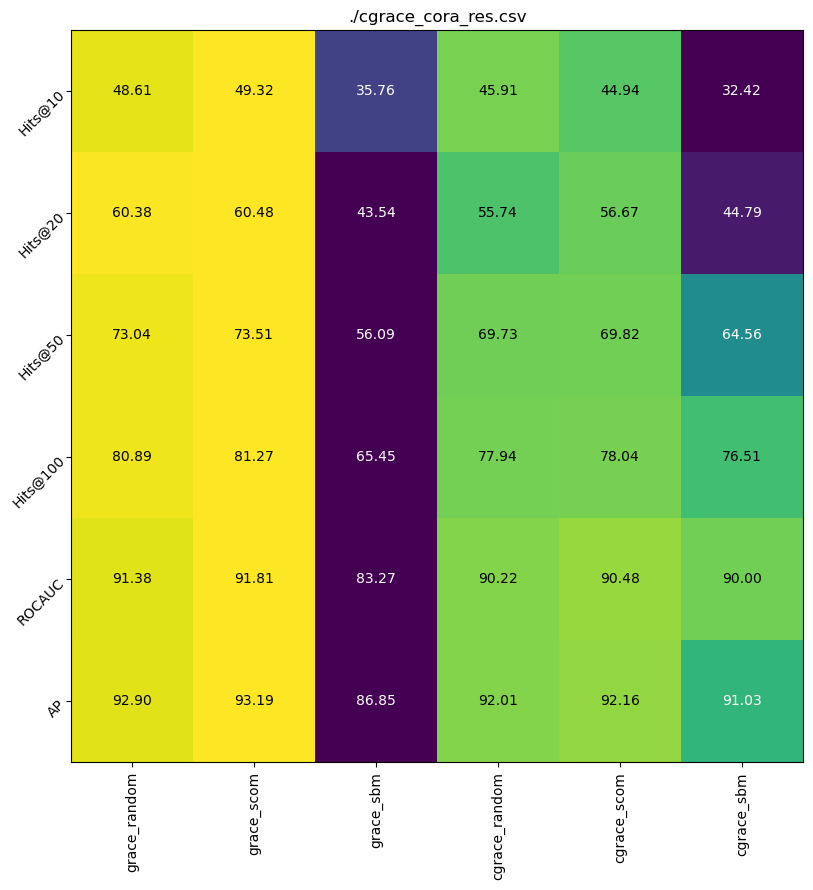

,grace_random,grace_scom,grace_sbm,cgrace_random,cgrace_scom,cgrace_sbm
metrics,,,,,,
Hits@10,48.61$\pm$3.7,49.32$\pm$6.01,35.76$\pm$3.88,45.91$\pm$4.71,44.94$\pm$5.28,32.42$\pm$5.29
Hits@20,60.38$\pm$2.55,60.48$\pm$4.56,43.54$\pm$3.48,55.74$\pm$3.58,56.67$\pm$2.86,44.79$\pm$5.69
Hits@50,73.04$\pm$2.12,73.51$\pm$2.4,56.09$\pm$1.49,69.73$\pm$1.75,69.82$\pm$1.42,64.56$\pm$3.78
Hits@100,80.89$\pm$1.4,81.27$\pm$1.58,65.45$\pm$1.7,77.94$\pm$1.35,78.04$\pm$0.98,76.51$\pm$1.68
ROCAUC,91.38$\pm$0.95,91.81$\pm$0.84,83.27$\pm$1.13,90.22$\pm$0.75,90.48$\pm$0.52,90.0$\pm$0.78
AP,92.9$\pm$0.58,93.19$\pm$0.51,86.85$\pm$0.79,92.01$\pm$0.5,92.16$\pm$0.42,91.03$\pm$0.74
pretrain_time,26.45$\pm$0.83,28.58$\pm$0.81,992.57$\pm$35.29,90.0$\pm$8.23,92.72$\pm$10.07,1006.58$\pm$44.02


In [4]:
name = './cgrace_cora_res.csv'
data = res_load(name)

print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name, (9,9))
display(data.T)

In [5]:
name_1 = './agrace_cora_res.csv'
data_1 = res_load(name)

name_2 = './full_output_cora_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm']].T

data = pd.concat([data_1, data_2])


print(name)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name, (9,9))
display(data.T)

./cgrace_cora_res.csv


TypeError: Could not convert string '48.61$\pm$3.760.38$\pm$2.5573.04$\pm$2.1280.89$\pm$1.491.38$\pm$0.9592.9$\pm$0.58' to numeric

./lgrace_cora_res.csv


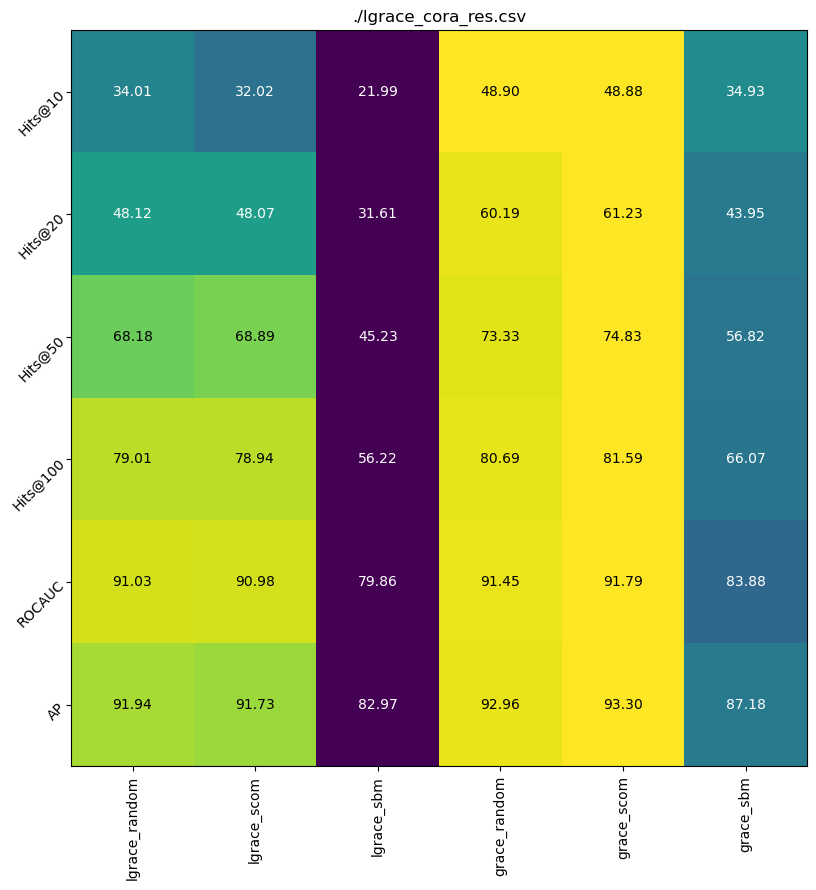

,lgrace_random,lgrace_scom,lgrace_sbm,grace_random,grace_scom,grace_sbm
metrics,,,,,,
Hits@10,34.01$\pm$6.52,32.02$\pm$3.95,21.99$\pm$4.65,48.9$\pm$4.88,48.88$\pm$6.25,34.93$\pm$4.84
Hits@20,48.12$\pm$4.71,48.07$\pm$4.81,31.61$\pm$3.24,60.19$\pm$2.76,61.23$\pm$4.28,43.95$\pm$3.63
Hits@50,68.18$\pm$2.32,68.89$\pm$2.97,45.23$\pm$1.47,73.33$\pm$1.73,74.83$\pm$1.53,56.82$\pm$2.11
Hits@100,79.01$\pm$1.67,78.94$\pm$1.05,56.22$\pm$2.27,80.69$\pm$1.6,81.59$\pm$1.4,66.07$\pm$2.04
ROCAUC,91.03$\pm$0.76,90.98$\pm$0.51,79.86$\pm$1.31,91.45$\pm$0.81,91.79$\pm$0.71,83.88$\pm$1.02
AP,91.94$\pm$0.58,91.73$\pm$0.48,82.97$\pm$0.78,92.96$\pm$0.6,93.3$\pm$0.44,87.18$\pm$0.72
pretrain_time,83.32$\pm$0.86,83.33$\pm$0.72,402.89$\pm$16.21,19.04$\pm$0.13,20.27$\pm$0.09,866.8$\pm$23.27


In [ ]:
name_1 = './lgrace_cora_res.csv'
data_1 = res_load(name_1)

name_2 = './full_output_cora_res.csv'
data_2 = res_load(name_2)
data_2 = data_2.T[['grace_random', 'grace_scom', 'grace_sbm']].T

data = pd.concat([data_1, data_2])


print(name_1)
# print(data.to_latex(
#         index=True, formatters={"name": str.upper}, float_format="{:.1f}".format
#     ))
heatmap(data, name_1, (9,9))
display(data.T)